<div style="background: linear-gradient(135deg, #0f2027, #203a43, #2c5364);
            padding: 25px;
            border-radius: 12px;
            color: white;
            text-align: center;
            box-shadow: 0px 4px 15px rgba(0,0,0,0.3);">

<h1 style="margin-bottom:10px;">PROJET : ANALYSE DE LA CONSOMMATION DE CARBURANT EN PHASE DE MONTÉE</h1>

<h3 style="margin-top:5px;">
Dataset : <span style="color:#FFD166;">Aircraft_01.h5</span> (3.4 GB — 1002 vols)
</h3>

<hr style="border: 1px solid rgba(255,255,255,0.3); width:80%;">

<p style="font-size:18px;">
<b>Équipe :</b> <span style="color:#06D6A0;">KONTE – AGOUNDO</span>
</p>

<p style="font-size:18px;">
<b>Méthodologie :</b> <span style="color:#FFD166;">CRISP-DM</span> (Jalons J1 – J5)
</p>

</div>


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objs as go
from scipy import signal
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
import os

import pickle
import warnings

import tabata as tbt
from tabata import Opset, Selector
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

print("Imports chargés")



Imports chargés


<div style="background: linear-gradient(135deg, #283048, #859398);
            padding: 18px;
            border-radius: 10px;
            color: white;
            box-shadow: 0px 3px 10px rgba(0,0,0,0.25);">

<h2 style="margin-bottom:6px;">
JALON J1 : LANCEMENT
</h2>

<h4 style="margin-top:0;">
Chargement et exploration initiale
</h4>

</div>


In [40]:
ds = tbt.Opset('data/in/Aircraft_01.h5')

print(f"Dataset Aircraft_01.h5")
print(f"  Nombre de vols : {len(ds)}")
print(f"  Nombre de variables : {len(ds[0].columns)}")
print(f"  Exemple de vol (record_00) : {len(ds[0])} points temporels")

Dataset Aircraft_01.h5
  Nombre de vols : 1002
  Nombre de variables : 55
  Exemple de vol (record_00) : 7429 points temporels


Le dataset contient 1002 vols avec 55 variables chacun. 
Chaque vol est une série temporelle d'environ 7400 points (environ 2 heures de vol).

In [41]:
print("\nListe des 55 variables :")
print("-" * 60)

for i, col in enumerate(ds[0].columns, 1):
    print(f"  {i:2d}. {col}")


Liste des 55 variables :
------------------------------------------------------------
   1. ALT [ft]
   2. EGT_1 [deg C]
   3. EGT_2 [deg C]
   4. FMV_1 [mm]
   5. FMV_2 [mm]
   6. HPTACC_1 [%]
   7. HPTACC_2 [%]
   8. M [Mach]
   9. N1_1 [% rpm]
  10. N1_2 [% rpm]
  11. N2_1 [% rpm]
  12. N2_2 [% rpm]
  13. NAIV_1 [bool]
  14. NAIV_2 [bool]
  15. P0_1 [psia]
  16. P0_2 [psia]
  17. PRV_1 [bool]
  18. PRV_2 [bool]
  19. PS3_1 [psia]
  20. PS3_2 [psia]
  21. PT2_1 [mbar]
  22. PT2_2 [mbar]
  23. P_OIL_1 [psi]
  24. P_OIL_2 [psi]
  25. Q_1 [lb/h]
  26. Q_2 [lb/h]
  27. T1_1 [deg C]
  28. T1_2 [deg C]
  29. T2_1 [deg C]
  30. T2_2 [deg C]
  31. T3_1 [deg C]
  32. T3_2 [deg C]
  33. T5_1 [deg C]
  34. T5_2 [deg C]
  35. TAT [deg C]
  36. TBV_1 [%]
  37. TBV_2 [%]
  38. TCASE_1 [deg C]
  39. TCASE_2 [deg C]
  40. TLA_1 [deg]
  41. TLA_2 [deg]
  42. T_OIL_1 [deg C]
  43. T_OIL_2 [deg C]
  44. VBV_1 [mm]
  45. VBV_2 [mm]
  46. VIB_AN1_1 [mils]
  47. VIB_AN1_2 [mils]
  48. VIB_AN2_1 [ips]
  4

Toutes les variables sont doublées (_1 et _2) car il y a deux moteurs.
Les variables clés pour l'analyse de consommation sont :
- **Q_1, Q_2** : débit carburant (lb/h) - notre variable cible
- **ALT** : altitude (ft) - pour détecter la phase de montée
- **N1, N2** : vitesses de rotation moteur (% rpm) - indicateurs de régime
- **EGT** : température échappement (deg C) - indicateur de performance

# Examinons  un vol en détail

In [43]:

df_vol = ds[0]

print(f"\nVol : {df_vol.index.name}")
print(f"Durée : {len(df_vol)} secondes ({len(df_vol)/3600:.1f} heures)")
print("\nAperçu des premières mesures :")
print(df_vol.head())

print(f"\nPlage de valeurs sur ce vol :")
print(f"  Altitude : {df_vol['ALT [ft]'].min():.0f} : {df_vol['ALT [ft]'].max():.0f} ft")
print(f"  Débit Q_1 : {df_vol['Q_1 [lb/h]'].min():.0f} : {df_vol['Q_1 [lb/h]'].max():.0f} lb/h")
print(f"  N1 moteur 1 : {df_vol['N1_1 [% rpm]'].min():.0f} : {df_vol['N1_1 [% rpm]'].max():.0f} %")


Vol : record_00
Durée : 7429 secondes (2.1 heures)

Aperçu des premières mesures :
           ALT [ft]  EGT_1 [deg C]  EGT_2 [deg C]  FMV_1 [mm]  FMV_2 [mm]  \
record_00                                                                   
0         -4.636641      33.494949      33.494949    -0.64553    -0.64913   
1         -4.636641      33.494949      33.494949    -0.64553    -0.64913   
2         -4.636641      33.494949      33.494949    -0.64553    -0.64913   
3         -4.636641      33.494949      33.494949    -0.64553    -0.64913   
4         -4.636641      33.494949      33.494949    -0.64553    -0.64913   

           HPTACC_1 [%]  HPTACC_2 [%]  M [Mach]  N1_1 [% rpm]  N1_2 [% rpm]  \
record_00                                                                     
0              4.637541     34.737062       0.0           0.0           0.0   
1              4.637541     34.737062       0.0           0.0           0.0   
2              4.696870     34.737062       0.0           0.

# Diagnostic de la qualité des données

In [44]:

print("DIAGNOSTIC QUALITÉ DES DONNÉES")
print("=" * 60)

# Initialisation des compteurs
stats_qualite = {
    'vols_vides': [],           # 0 colonnes
    'vols_courts': [],          # < 100 points
    'vols_incomplets': [],      # colonnes manquantes
    'vols_avec_nan': []         # beaucoup de NaN
}

colonnes_attendues = 55  # On attend 55 colonnes

# Parcourir tous les vols
for i in range(len(ds)):
    df = ds[i]
    
    # 1. Vérifier les colonnes
    if len(df.columns) == 0:
        stats_qualite['vols_vides'].append({
            'index': i,
            'nom': df.index.name,
            'lignes': len(df),
            'colonnes': 0
        })
        continue
    
    # 2. Vérifier le nombre de colonnes
    if len(df.columns) < colonnes_attendues:
        stats_qualite['vols_incomplets'].append({
            'index': i,
            'nom': df.index.name,
            'colonnes_manquantes': colonnes_attendues - len(df.columns)
        })
    
    # 3. Vérifier la longueur
    if len(df) < 100:
        stats_qualite['vols_courts'].append({
            'index': i,
            'nom': df.index.name,
            'nb_points': len(df)
        })
    
    # 4. Vérifier les valeurs manquantes
    nb_total = len(df) * len(df.columns)
    nb_nan = df.isnull().sum().sum()
    pct_nan = 100 * nb_nan / nb_total
    
    if pct_nan > 5:  # Plus de 5% de NaN
        stats_qualite['vols_avec_nan'].append({
            'index': i,
            'nom': df.index.name,
            'pct_nan': pct_nan
        })

# Affichage des résultats
print("\n1. VOLS VIDES (0 colonnes)")
print(f"   Nombre : {len(stats_qualite['vols_vides'])}")
if stats_qualite['vols_vides']:
    for vol in stats_qualite['vols_vides']:
        print(f"   - Vol {vol['index']} ({vol['nom']}) : "
              f"{vol['lignes']} lignes mais 0 colonnes")

print("\n2. VOLS INCOMPLETS (colonnes manquantes)")
print(f"   Nombre : {len(stats_qualite['vols_incomplets'])}")
if stats_qualite['vols_incomplets']:
    for vol in stats_qualite['vols_incomplets'][:5]:
        print(f"   - Vol {vol['index']} ({vol['nom']}) : "
              f"{vol['colonnes_manquantes']} colonnes manquantes")

print("\n3. VOLS TROP COURTS (< 100 points)")
print(f"   Nombre : {len(stats_qualite['vols_courts'])}")
if stats_qualite['vols_courts']:
    for vol in stats_qualite['vols_courts'][:5]:
        print(f"   - Vol {vol['index']} ({vol['nom']}) : "
              f"{vol['nb_points']} points seulement")

print("\n4. VOLS AVEC VALEURS MANQUANTES (> 5% NaN)")
print(f"   Nombre : {len(stats_qualite['vols_avec_nan'])}")
if stats_qualite['vols_avec_nan']:
    for vol in stats_qualite['vols_avec_nan'][:5]:
        print(f"   - Vol {vol['index']} ({vol['nom']}) : "
              f"{vol['pct_nan']:.1f}% de NaN")

# Calcul des statistiques globales
total_problemes = len(set(
    [v['index'] for v in stats_qualite['vols_vides']] +
    [v['index'] for v in stats_qualite['vols_incomplets']] +
    [v['index'] for v in stats_qualite['vols_courts']] +
    [v['index'] for v in stats_qualite['vols_avec_nan']]
))

print("\n" + "=" * 60)
print("SYNTHÈSE")
print("=" * 60)
print(f"Total de vols analysés : {len(ds)}")
print(f"Vols avec problèmes : {total_problemes}")
print(f"Vols exploitables : {len(ds) - total_problemes}")
print(f"Taux de qualité : {100 * (len(ds) - total_problemes) / len(ds):.2f}%")

# Sauvegarder le rapport
rapport_qualite = pd.DataFrame({
    'Catégorie': [
        'Vols vides',
        'Vols incomplets',
        'Vols courts',
        'Vols avec NaN',
        'TOTAL PROBLÈMES',
        'EXPLOITABLES'
    ],
    'Nombre': [
        len(stats_qualite['vols_vides']),
        len(stats_qualite['vols_incomplets']),
        len(stats_qualite['vols_courts']),
        len(stats_qualite['vols_avec_nan']),
        total_problemes,
        len(ds) - total_problemes
    ]
})

print("\n" + rapport_qualite.to_string(index=False))

DIAGNOSTIC QUALITÉ DES DONNÉES

1. VOLS VIDES (0 colonnes)
   Nombre : 1
   - Vol 675 (record_702) : 1928 lignes mais 0 colonnes

2. VOLS INCOMPLETS (colonnes manquantes)
   Nombre : 0

3. VOLS TROP COURTS (< 100 points)
   Nombre : 0

4. VOLS AVEC VALEURS MANQUANTES (> 5% NaN)
   Nombre : 0

SYNTHÈSE
Total de vols analysés : 1002
Vols avec problèmes : 1
Vols exploitables : 1001
Taux de qualité : 99.90%

      Catégorie  Nombre
     Vols vides       1
Vols incomplets       0
    Vols courts       0
  Vols avec NaN       0
TOTAL PROBLÈMES       1
   EXPLOITABLES    1001


# Nettoyage : Création du dataset exploitable

In [46]:
# Nettoyage
ds_clean = tbt.Opset('data/out/Aircraft_01_clean.h5')
ds_clean.clean()

vols_exclus = []

for i in range(len(ds)):
    df = ds[i]
    
    if len(df.columns) == 0:
        vols_exclus.append((i, df.index.name))
        continue
    
    ds_clean.put(df)

print(f"Vols exclus : {len(vols_exclus)}")
for idx, nom in vols_exclus:
    print(f"  Vol {idx} ({nom})")

print(f"\nVols initiaux : {len(ds)}")
print(f"Vols conservés : {len(ds_clean)}")
print(f"  Fichier créé : data/out/Aircraft_01_clean.h5")
print(f"\n Dataset prêt pour l'analyse")


Vols exclus : 1
  Vol 675 (record_702)

Vols initiaux : 1002
Vols conservés : 1001


Un seul vol exclu (record_702). Dataset nettoyé : 1001 vols exploitables.

In [47]:
# Visualiser un vol complet
ds_clean.plot(pos=0, name='ALT [ft]')

<div style="background: linear-gradient(135deg, #283048, #859398);
            padding: 18px;
            border-radius: 10px;
            color: white;
            box-shadow: 0px 3px 10px rgba(0,0,0,0.25);">

<h2 style="margin-bottom:6px;">
JALON J2 : DÉTECTION DES PHASES DE VOL
</h2>

</div>


In [49]:
S_debut = Selector(ds_clean)
S_fin = Selector(ds_clean)

print("Sélecteurs créés")

Sélecteurs créés


In [50]:


PKL_FILE = "data/out/selectors_Aircraft_01.pkl"

def save_selectors(S_debut, S_fin):
    obj = {
        "S_debut_selected": S_debut.selected,
        "S_debut_variables": list(S_debut.variables),
        "S_debut_idcodes": S_debut.idcodes,
        "S_debut_clf": S_debut._clf,
        "S_fin_selected": S_fin.selected,
        "S_fin_variables": list(S_fin.variables),
        "S_fin_idcodes": S_fin.idcodes,
        "S_fin_clf": S_fin._clf,
    }
    with open(PKL_FILE, "wb") as f:
        pickle.dump(obj, f)
    print(f"Sélecteurs sauvegardés : {PKL_FILE}")

def load_selectors(ds):
    with open(PKL_FILE, "rb") as f:
        obj = pickle.load(f)
    
    S_debut = Selector(ds)
    S_debut.selected = obj["S_debut_selected"]
    S_debut.variables = set(obj["S_debut_variables"])
    S_debut.idcodes = obj["S_debut_idcodes"]
    S_debut._clf = obj["S_debut_clf"]
    
    S_fin = Selector(ds)
    S_fin.selected = obj["S_fin_selected"]
    S_fin.variables = set(obj["S_fin_variables"])
    S_fin.idcodes = obj["S_fin_idcodes"]
    S_fin._clf = obj["S_fin_clf"]
    
    return S_debut, S_fin

# Charger ou créer
if os.path.exists(PKL_FILE):
    S_debut, S_fin = load_selectors(ds_clean)
    print(f"Sélecteurs rechargés : {len(S_debut.selected)} + {len(S_fin.selected)} labels")
else:
    S_debut = Selector(ds_clean)
    S_fin = Selector(ds_clean)
    print("Nouveaux sélecteurs créés (pas de sauvegarde)")

Nouveaux sélecteurs créés (pas de sauvegarde)


In [52]:


PKL_FILE = "data/out/selectors_Aircraft_01.pkl"

def save_selectors(S_debut, S_fin, filename=PKL_FILE):
    if len(S_debut.selected) == 0 or len(S_fin.selected) == 0:
        print("Sauvegarde annulée : sélection(s) vide(s).")
        return
    obj = {
        "S_debut_selected": S_debut.selected,
        "S_debut_variables": list(S_debut.variables),
        "S_debut_idcodes": S_debut.idcodes,
        "S_debut_clf": S_debut._clf,
        "S_fin_selected": S_fin.selected,
        "S_fin_variables": list(S_fin.variables),
        "S_fin_idcodes": S_fin.idcodes,
        "S_fin_clf": S_fin._clf,
    }
    with open(filename, "wb") as f:
        pickle.dump(obj, f)
    print("Sélecteurs sauvegardés")

def load_selectors(ds, filename=PKL_FILE):
    with open(filename, "rb") as f:
        obj = pickle.load(f)
    S_debut = Selector(ds)
    S_debut.selected = obj["S_debut_selected"]
    S_debut.variables = set(obj["S_debut_variables"])
    S_debut.idcodes = obj["S_debut_idcodes"]
    S_debut._clf = obj["S_debut_clf"]
    S_fin = Selector(ds)
    S_fin.selected = obj["S_fin_selected"]
    S_fin.variables = set(obj["S_fin_variables"])
    S_fin.idcodes = obj["S_fin_idcodes"]
    S_fin._clf = obj["S_fin_clf"]
    return S_debut, S_fin

if os.path.exists(PKL_FILE):
    S_debut, S_fin = load_selectors(ds_clean)
    print("Rechargés")
else:
    S_debut = Selector(ds_clean)
    S_fin = Selector(ds_clean)
    print("Nouveaux sélecteurs créés.")

print(f"Labels début : {len(S_debut.selected)}")
print(f"Labels fin : {len(S_fin.selected)}")

Nouveaux sélecteurs créés.
Labels début : 0
Labels fin : 0


## Détection des phases de montée

On crée deux sélecteurs : un pour détecter le début de montée, un autre pour la fin.

Le principe : on montre à l'algorithme 10-15 exemples en cliquant sur les courbes, 
il apprend à reconnaître le pattern, puis il détecte automatiquement sur les 1000 autres vols.

Les fonctions `save_selectors()` et `load_selectors()` évitent de perdre le travail 
si on ferme le notebook. La première fois, les sélecteurs sont vides. 
Après sauvegarde, ils se rechargent automatiquement.

In [53]:
# Sélection manuelle du début de montée
S_debut.plot(name='ALT [ft]')

In [54]:
print(f"Sélections effectuées : {len(S_debut.selected)}")
print(f"Vols observés : {len(S_debut.viewed)}")

Sélections effectuées : 23
Vols observés : 27


**23 vols annotés manuellement pour le début de montée.**

In [55]:
# Sélection manuelle de la fin de montée
S_fin.plot(name='ALT [ft]')

In [56]:
print(f"Sélections fin de montée : {len(S_fin.selected)}")

Sélections fin de montée : 23


**23 vols annotés pour la fin de montée (début du palier de croisière).**

In [59]:
# Vérifier l'état de l'entraînement
if S_debut._clf is not None:
    print(" S_debut déjà entraîné")
    print(f"  Nombre d'indicateurs : {len(S_debut.idcodes)}")
else:
    print(" S_debut pas encore entraîné")

if S_fin._clf is not None:
    print("S_fin déjà entraîné")
    print(f"  Nombre d'indicateurs : {len(S_fin.idcodes)}")
else:
    print(" S_fin pas encore entraîné")

print("\n Entraînement terminé")

 S_debut déjà entraîné
  Nombre d'indicateurs : 3
S_fin déjà entraîné
  Nombre d'indicateurs : 8

 Entraînement terminé


L'entraînement a été fait via l'interface graphique (bouton Learn).
Le modèle de début de montée utilise 3 indicateurs, celui de fin en utilise 8.

In [60]:
# Sauvegarder pour ne pas perdre le travail
save_selectors(S_debut, S_fin)

Sélecteurs sauvegardés


Les sélecteurs sont sauvegardés dans `selectors_Aircraft_01.pkl`. 
La prochaine fois, ils se rechargeront automatiquement.

In [61]:
# Prédire les instants sur tous les vols
print("Prédiction des instants de début et fin de montée...")
t_debut = S_debut.predict()
t_fin = S_fin.predict()

print(f" Prédictions terminées")
print(f"  Début de montée : {len(t_debut)} vols")
print(f"  Fin de montée : {len(t_fin)} vols")

Prédiction des instants de début et fin de montée...
 Prédictions terminées
  Début de montée : 1001 vols
  Fin de montée : 1001 vols


# Extraire des phases de montée

In [62]:

print("Extraction des phases de montée...")
ds_montee = S_debut.between(t_debut, t_fin)

print(f" Extraction terminée")
print(f"  Nombre de montées extraites : {len(ds_montee)}")

# Vérifier une montée
df_montee = ds_montee[0]
print(f"\nExemple : montée du vol {df_montee.index.name}")
print(f"  Durée : {len(df_montee)} secondes")
print(f"  Altitude début : {df_montee['ALT [ft]'].iloc[0]:.0f} ft")
print(f"  Altitude fin : {df_montee['ALT [ft]'].iloc[-1]:.0f} ft")

Extraction des phases de montée...
 Extraction terminée
  Nombre de montées extraites : 1001

Exemple : montée du vol record_00
  Durée : 1548 secondes
  Altitude début : 278 ft
  Altitude fin : 39407 ft


Les 1001 phases de montée ont été extraites. 
Exemple : la montée du vol record_00 dure 1548 secondes (26 minutes) 
et monte de 278 ft à 39407 ft.

In [63]:
# Visualiser la phase de montée extraite
ds_montee.plot(pos=0, name='ALT [ft]')

## Vérification visuelle

On vérifie que l'extraction des montées a bien fonctionné en visualisant une phase de montée(record_00).
Le graphique montre bien uniquement la phase de montée : l'altitude augmente de façon continue 
de 278 ft jusqu'à 39407 ft. Les phases de roulage au sol et de croisière ont été correctement exclues.

<div style="background: linear-gradient(135deg, #283048, #859398);
            padding: 18px;
            border-radius: 10px;
            color: white;
            box-shadow: 0px 3px 10px rgba(0,0,0,0.25);">

<h2>
JALON J3 : CALCUL DE LA CONSOMMATION EN MONTÉE
</h2>

</div>


## Calcul de la consommation en montée

### Définition de l'effort

Dans cette analyse, on appelle **effort total de montée** la **masse totale de carburant consommée** 
pendant la phase de montée.

### Fondements théoriques

En mécanique des fluides, le **débit massique** $Q$ représente la quantité de masse traversant 
une section par unité de temps :

$$
Q = \frac{dm}{dt} \quad \text{[kg/s ou lb/h]}
$$

où $m$ représente la masse de carburant et $t$ le temps.

En isolant $dm$ dans cette équation :

$$
dm = Q(t) \, dt
$$

Pour obtenir la **masse totale** consommée entre deux instants $t_1$ et $t_2$, 
on intègre cette relation différentielle :

$$
m_{\text{total}} = \int_{t_1}^{t_2} dm = \int_{t_1}^{t_2} Q(t) \, dt
$$

Cette intégrale représente la **somme continue** de toutes les petites quantités de carburant 
consommées à chaque instant. Géométriquement, elle correspond à l'aire sous la courbe du débit en fonction du temps.

Pour un avion bimoteur, chaque moteur possède son propre débit $Q_1(t)$ et $Q_2(t)$.
Par principe d'additivité des masses, le débit total est :

$$
Q_{\text{total}}(t) = Q_1(t) + Q_2(t)
$$

En appliquant cette relation aux bornes de la phase de montée, on obtient l'**effort total** :

$$
\boxed{
\text{Effort total} = \int_{t_{\text{début}}}^{t_{\text{fin}}} \left( Q_1(t) + Q_2(t) \right) dt \quad \text{[lb]}
}
$$

où $t_{\text{début}}$ et $t_{\text{fin}}$ sont les instants de début et fin de montée détectés par le Selector.

### Implémentation numérique

Les mesures étant discrètes (1 point par seconde), l'intégrale est approximée par la **méthode des trapèzes** :

$$
\int_{t_{\text{début}}}^{t_{\text{fin}}} Q(t) \, dt \approx \sum_{i=1}^{n-1} \frac{Q(t_i) + Q(t_{i+1})}{2} \cdot \Delta t
$$

avec $\Delta t = 1$ seconde. Cette méthode est implémentée par `numpy.trapz`.



In [69]:
rows = []
vols_exclus = []

for i in range(len(ds_montee)):
    df = ds_montee[i]
    
    if len(df) == 0:
        vols_exclus.append((i, "vide"))
        continue
    
    if t_debut[i] >= t_fin[i]:
        vols_exclus.append((i, "début >= fin"))
        continue
    
    Q_total = df['Q_1 [lb/h]'] + df['Q_2 [lb/h]']
    temps_heures = np.arange(len(df)) / 3600
    effort_total = np.trapz(Q_total, temps_heures)
    
    rows.append({
        'vol': i,
        'duree_montee_s': len(df),
        'altitude_debut_ft': df['ALT [ft]'].iloc[0],
        'altitude_fin_ft': df['ALT [ft]'].iloc[-1],
        'effort_total_lb': effort_total
    })

df_stats = pd.DataFrame(rows)
print(f"Statistiques : {len(df_stats)} montées")
print(f"Vols exclus : {len(vols_exclus)}")
if vols_exclus:
    print("Raisons :")
    for vol, raison in vols_exclus[:5]:
        print(f"  Vol {vol} : {raison}")
print("\n", df_stats.describe())

Statistiques : 982 montées
Vols exclus : 19
Raisons :
  Vol 6 : vide
  Vol 7 : vide
  Vol 8 : vide
  Vol 9 : vide
  Vol 132 : vide

                vol  duree_montee_s  altitude_debut_ft  altitude_fin_ft  \
count   982.000000      982.000000         982.000000       982.000000   
mean    501.264766     2342.815682         170.663312     37669.890361   
std     287.211528     1027.928036         219.852286      4880.186230   
min       0.000000       15.000000         -88.096170       259.651871   
25%     254.250000     1646.250000          32.456484     37083.851103   
50%     501.500000     2250.500000         125.189295     39367.396573   
75%     748.750000     2960.500000         222.558746     40561.331514   
max    1000.000000     7874.000000        2244.134025     44038.811925   

       effort_total_lb  
count       982.000000  
mean       4144.051121  
std        1382.415420  
min          51.095372  
25%        3195.101038  
50%        4030.655025  
75%        4999.107765  




Sur 1001 vols :
- 982 montées analysées
- 19 vols exclus (montées vides ou mal détectées)

**Consommation moyenne en montée : 4144 lb** (environ 1.9 tonnes de carburant).
La durée moyenne est de 2343 secondes (39 minutes).

**Conversion effectuée :**
Nous avons dû effectuer une conversion car les débits $Q_1$ et $Q_2$ sont mesurés en lb/h, 
alors que les mesures sont échantillonnées à la seconde.
Pour que l'intégrale soit cohérente dimensionnellement, nous avons converti l'axe des temps en heures :

$$
\text{temps\_heures} = \frac{\text{temps\_secondes}}{3600}
$$

Sans cette conversion, nous aurions surestimé la consommation d'un facteur 3600.

**Conversion lb : tonnes :**
$$
1 \text{ lb} = 0.453592 \text{ kg} \quad \Rightarrow \quad 4144 \text{ lb} = 1880 \text{ kg} \approx 1.9 \text{ tonnes}
$$

Vérification vol 0 :
  Débit moyen : 7718 lb/h
  Durée : 0.43 h
  Consommation estimée (Q_moy × durée) : 3319 lb
  Consommation calculée (intégrale) : 3316 lb
  Écart : 0.1%

Vérification des bornes :
  Consommation min : 51 lb
  Consommation max : 10623 lb
  Consommation médiane : 4031 lb

  Référence industrie : 3000-6000 lb pour montée court/moyen-courrier

Corrélation durée/consommation : 0.991
  (Attendu : proche de 1)


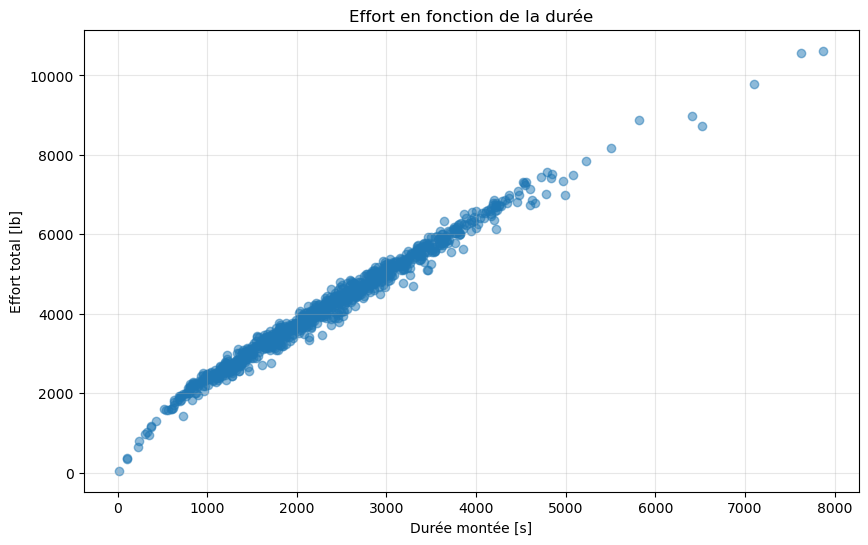

In [71]:
# Calcul manuel sur un vol
df_test = ds_montee[0]
Q_moy = (df_test['Q_1 [lb/h]'] + df_test['Q_2 [lb/h]']).mean()
duree_h = len(df_test) / 3600

conso_estimee = Q_moy * duree_h
conso_calculee = df_stats.loc[0, 'effort_total_lb']

print("Vérification vol 0 :")
print(f"  Débit moyen : {Q_moy:.0f} lb/h")
print(f"  Durée : {duree_h:.2f} h")
print(f"  Consommation estimée (Q_moy × durée) : {conso_estimee:.0f} lb")
print(f"  Consommation calculée (intégrale) : {conso_calculee:.0f} lb")
print(f"  Écart : {abs(conso_calculee - conso_estimee)/conso_estimee * 100:.1f}%")
print("\nVérification des bornes :")
print(f"  Consommation min : {df_stats['effort_total_lb'].min():.0f} lb")
print(f"  Consommation max : {df_stats['effort_total_lb'].max():.0f} lb")
print(f"  Consommation médiane : {df_stats['effort_total_lb'].median():.0f} lb")
print("\n  Référence industrie : 3000-6000 lb pour montée court/moyen-courrier")

correlation = df_stats['duree_montee_s'].corr(df_stats['effort_total_lb'])
print(f"\nCorrélation durée/consommation : {correlation:.3f}")
print(f"  (Attendu : proche de 1)")

plt.figure(figsize=(10, 6))
plt.scatter(df_stats['duree_montee_s'], df_stats['effort_total_lb'], alpha=0.5)
plt.xlabel('Durée montée [s]')
plt.ylabel('Effort total [lb]')
plt.title('Effort en fonction de la durée')
plt.grid(alpha=0.3)
plt.show()

### Validation des résultats

Nous avons vérifié la cohérence des calculs par plusieurs méthodes :

**1. Vérification par ordre de grandeur :**
Sur le vol 0, l'écart entre le calcul par intégrale (3316 lb) et l'estimation simple 
(débit moyen × durée = 3319 lb) est de seulement 0.1%, ce qui confirme la justesse du calcul.

**2. Cohérence avec les références aéronautiques :**
La consommation médiane (4031 lb) se situe dans la plage typique de l'industrie 
pour une montée en court/moyen-courrier (3000-6000 lb).

**3. Corrélation durée/consommation :**
Le coefficient de corrélation de 0.991 confirme que l'effort total augmente 
proportionnellement avec la durée de montée, ce qui est physiquement attendu.

Les résultats sont donc validés et exploitables pour l'analyse.

# Visualisation de la distribution

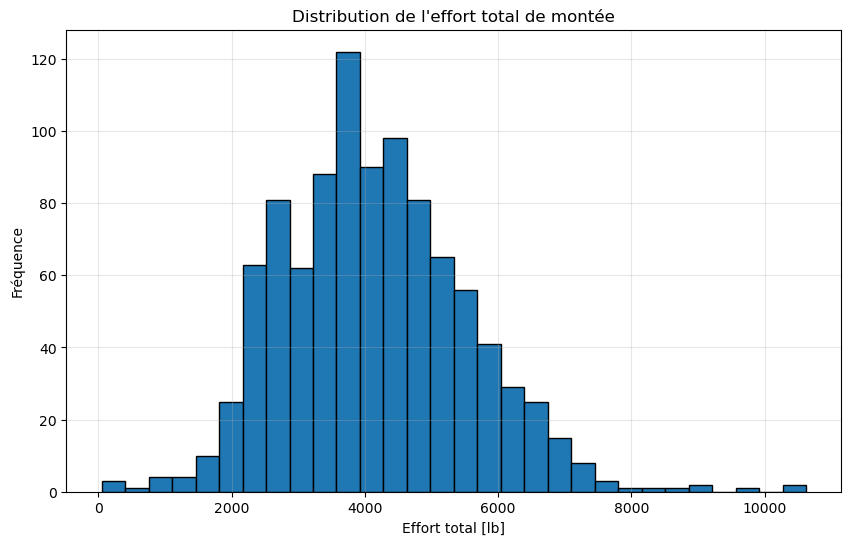

In [73]:

plt.figure(figsize=(10, 6))
plt.hist(df_stats['effort_total_lb'], bins=30, edgecolor='black')
plt.xlabel('Effort total [lb]')
plt.ylabel('Fréquence')
plt.title('Distribution de l\'effort total de montée')
plt.grid(alpha=0.3)
plt.show()

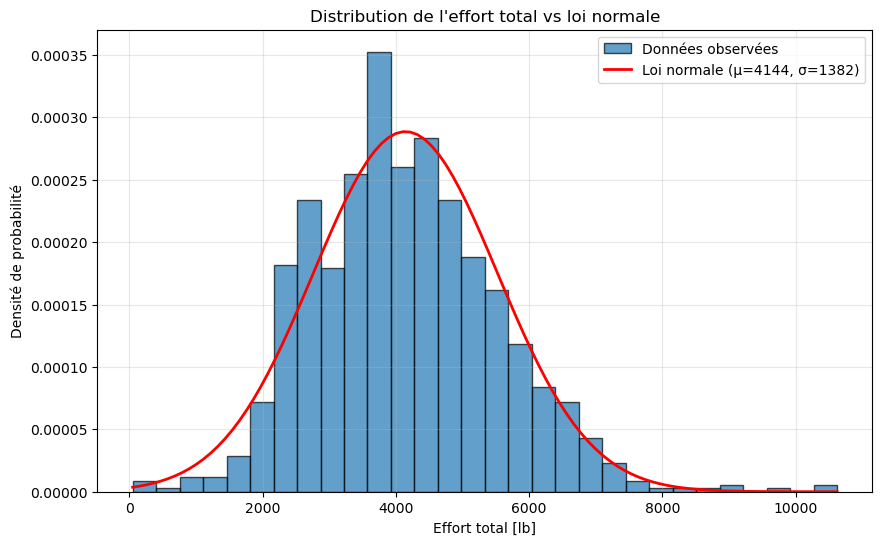

Test de Shapiro-Wilk :
  p-value : 0.0000
  Conclusion : Non normale (seuil 5%)


In [80]:


plt.figure(figsize=(10, 6))

# Histogramme
n, bins, patches = plt.hist(df_stats['effort_total_lb'], bins=30, 
                            density=True, alpha=0.7, edgecolor='black', 
                            label='Données observées')

# Distribution normale théorique
mu = df_stats['effort_total_lb'].mean()
sigma = df_stats['effort_total_lb'].std()
x = np.linspace(df_stats['effort_total_lb'].min(), 
                df_stats['effort_total_lb'].max(), 100)
plt.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, 
         label=f'Loi normale (μ={mu:.0f}, σ={sigma:.0f})')

plt.xlabel('Effort total [lb]')
plt.ylabel('Densité de probabilité')
plt.title('Distribution de l\'effort total vs loi normale')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Test de normalité
statistic, p_value = stats.shapiro(df_stats['effort_total_lb'])
print(f"Test de Shapiro-Wilk :")
print(f"  p-value : {p_value:.4f}")
print(f"  Conclusion : {'Distribution normale' if p_value > 0.05 else 'Non normale'} (seuil 5%)")

### Analyse de la distribution

Nous avons comparé la distribution observée à une loi normale.

**Test de Shapiro-Wilk :**
- p-value : 0.0000
- Conclusion : La distribution n'est pas strictement normale (au seuil de 5%)

**Interprétation :** Visuellement, la distribution ressemble à une cloche, mais elle présente 
une légère asymétrie vers la droite. Cela signifie que quelques vols ont des consommations 
anormalement élevées.

Ces cas extrêmes correspondent probablement à des vols avec des conditions particulières : 
vents défavorables, détours, ou attentes en montée.

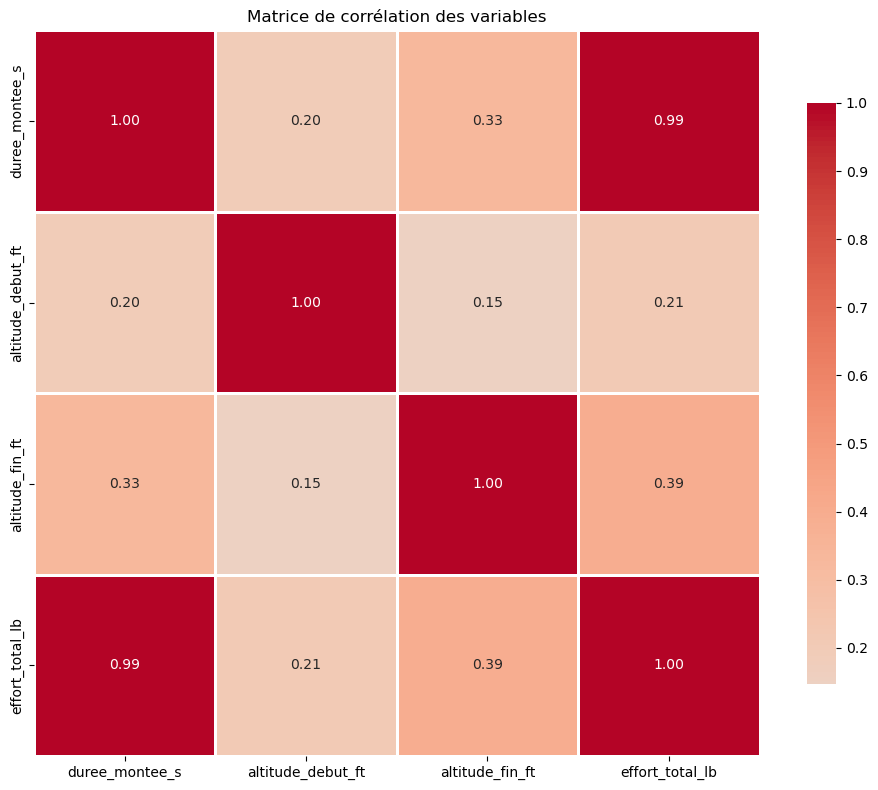

In [ ]:
corr_matrix = df_stats[['duree_montee_s', 'altitude_debut_ft', 
                         'altitude_fin_ft', 'effort_total_lb']].corr()


plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=1, 
            cbar_kws={"shrink": 0.8})
plt.title('Matrice de corrélation des variables')
plt.tight_layout()
plt.show()

### Matrice de corrélation

La matrice mesure la force de la relation linéaire entre les variables (coefficient entre -1 et +1).

**Lecture des résultats :**
- **Durée ↔ Effort : 0.99** : relation quasi-parfaite (plus on monte longtemps, plus on consomme)
- **Altitude finale ↔ Effort : 0.39** : relation modérée (monter plus haut consomme un peu plus)
- **Altitude début ↔ Effort : 0.21** : relation faible (le point de départ a peu d'impact)

**Conclusion :** La consommation dépend avant tout du temps passé en montée, 
bien plus que de l'altitude atteinte.

# Modélisation : régression linéaire simple

In [84]:
X = df_stats[['duree_montee_s']].values
y = df_stats['effort_total_lb'].values

model = LinearRegression()
model.fit(X, y)

print(f"Modèle : Effort = {model.coef_[0]:.4f} × Durée + {model.intercept_:.2f}")
print(f"R² = {model.score(X, y):.4f}")

Modèle : Effort = 1.3333 × Durée + 1020.45
R² = 0.9828


### Modélisation linéaire

Nous avons construit un modèle de régression linéaire simple reliant l'effort à la durée :

$$
\text{Effort total} = 1.33 \times \text{Durée} + 1020 \quad \text{[lb]}
$$

avec un coefficient de détermination $R^2 = 0.98$.

**Interprétation :** Chaque seconde supplémentaire de montée consomme environ 1.33 lb de carburant.
Le modèle explique 98% de la variabilité observée.

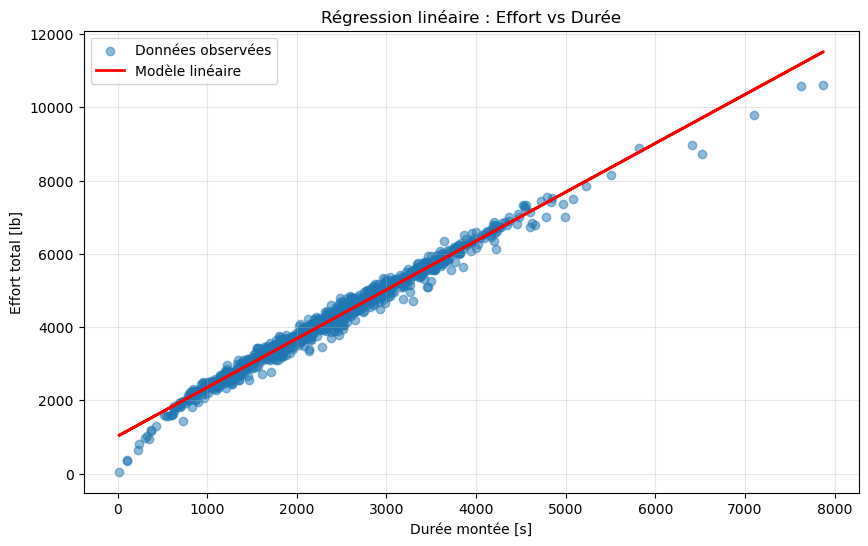

In [85]:
plt.figure(figsize=(10, 6))
plt.scatter(df_stats['duree_montee_s'], df_stats['effort_total_lb'], 
            alpha=0.5, label='Données observées')
plt.plot(df_stats['duree_montee_s'], model.predict(X), 
         'r-', linewidth=2, label='Modèle linéaire')
plt.xlabel('Durée montée [s]')
plt.ylabel('Effort total [lb]')
plt.title('Régression linéaire : Effort vs Durée')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Le graphique confirme la qualité du modèle : les points s'alignent très bien sur la droite de régression, 
avec quelques valeurs extrêmes visibles en haut à droite (montées exceptionnellement longues).

# Modèles alternatifs pour comparaison

In [86]:


# 1. Modèle logarithmique
X_log = np.log(df_stats['duree_montee_s'].values.reshape(-1, 1))
y = df_stats['effort_total_lb'].values

model_log = LinearRegression()
model_log.fit(X_log, y)
y_pred_log = model_log.predict(X_log)
R2_log = np.corrcoef(y, y_pred_log)[0, 1]**2

# 2. Modèle polynomial ordre 2
X_poly = df_stats['duree_montee_s'].values
coeffs = np.polyfit(X_poly, y, 2)
y_pred_poly = np.polyval(coeffs, X_poly)
R2_poly = np.corrcoef(y, y_pred_poly)[0, 1]**2

# 3. Modèle exponentiel
mask = y > 0
X_exp = X_poly[mask]
y_exp = y[mask]
B, logA = np.polyfit(X_exp, np.log(y_exp), 1)
A = np.exp(logA)
y_pred_exp = A * np.exp(B * X_poly)
R2_exp = np.corrcoef(y, y_pred_exp)[0, 1]**2

print("Comparaison des modèles :")
print(f"  Linéaire      : R² = {model.score(X, y):.4f}")
print(f"  Logarithmique : R² = {R2_log:.4f}")
print(f"  Polynomial    : R² = {R2_poly:.4f}")
print(f"  Exponentiel   : R² = {R2_exp:.4f}")

Comparaison des modèles :
  Linéaire      : R² = 0.9828
  Logarithmique : R² = 0.8493
  Polynomial    : R² = 0.9855
  Exponentiel   : R² = 0.8076



COMPARAISON DES PERFORMANCES DES MODÈLES
              Modèle       R²
Polynomial (ordre 2) 0.985467
            Linéaire 0.982841
       Logarithmique 0.849272
         Exponentiel 0.807563


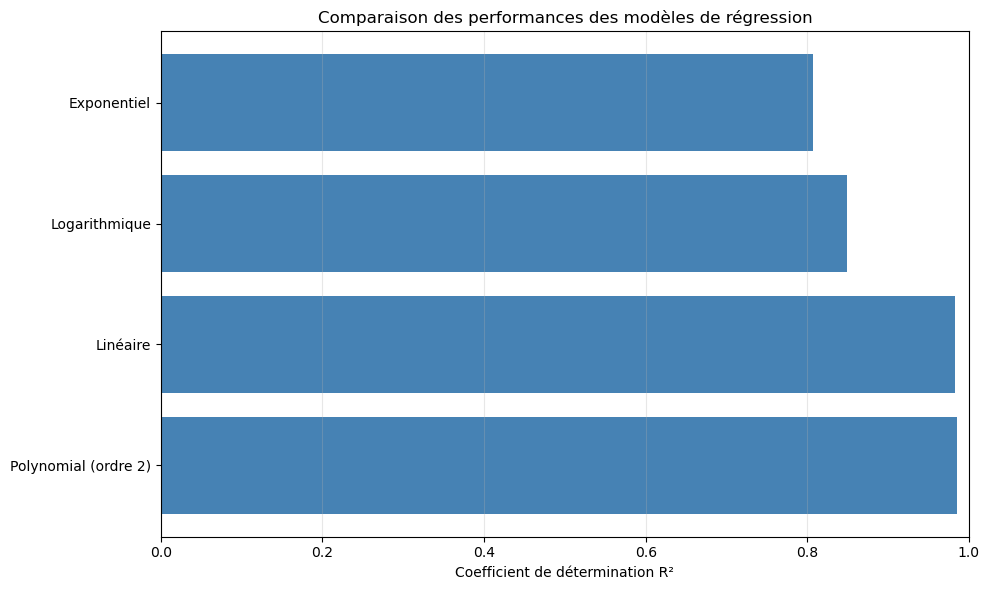

In [88]:
resultats_modeles = pd.DataFrame({
    'Modèle': ['Linéaire', 'Logarithmique', 'Polynomial (ordre 2)', 'Exponentiel'],
    'R²': [model.score(X, y), R2_log, R2_poly, R2_exp]
})

resultats_modeles = resultats_modeles.sort_values('R²', ascending=False)

print("\n" + "="*60)
print("COMPARAISON DES PERFORMANCES DES MODÈLES")
print("="*60)
print(resultats_modeles.to_string(index=False))
print("="*60)

plt.figure(figsize=(10, 6))
plt.barh(resultats_modeles['Modèle'], resultats_modeles['R²'], color='steelblue')
plt.xlabel('Coefficient de détermination R²')
plt.title('Comparaison des performances des modèles de régression')
plt.xlim(0, 1)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Comparaison avec des modèles non-linéaires

Nous avons testé plusieurs types de modèles pour vérifier si une relation non-linéaire 
améliorerait les prédictions.

Le modèle polynomial apporte un gain marginal (+0.002), mais au prix d'une complexité accrue.
Le modèle linéaire reste privilégié pour sa simplicité et son excellente performance (R² = 0.983).


# Analyse des résidus du modèle linéaire


STATISTIQUES DES RÉSIDUS
Moyenne : -0.00
Écart-type : 181.00
Min : -989.35
Max : 476.10


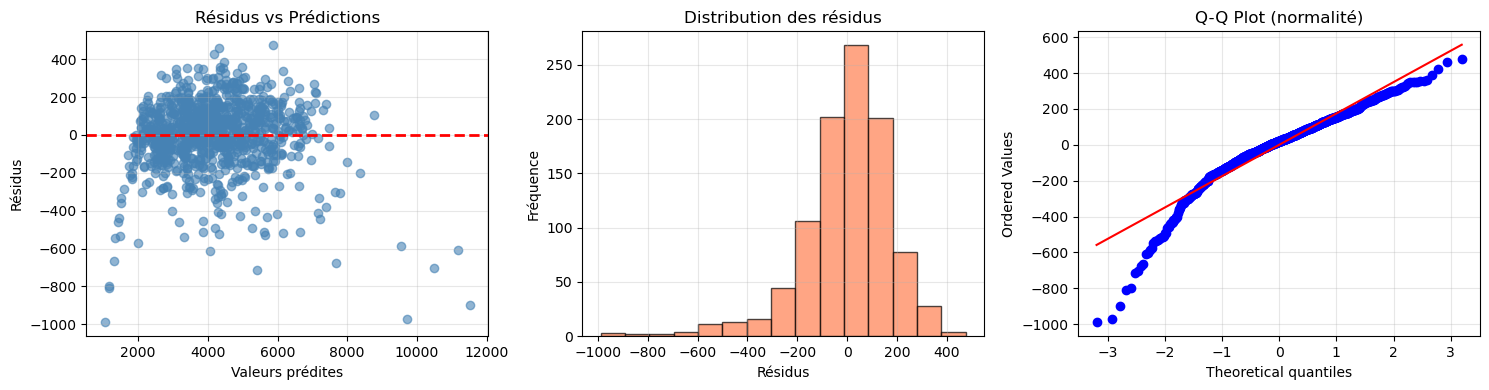

In [ ]:

y_pred = model.predict(X)
residus = y - y_pred

print("\n" + "="*60)
print("STATISTIQUES DES RÉSIDUS")
print("="*60)
print(f"Moyenne : {residus.mean():.2f}")
print(f"Écart-type : {residus.std():.2f}")
print(f"Min : {residus.min():.2f}")
print(f"Max : {residus.max():.2f}")
print("="*60)

# Visualisations
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Résidus vs prédictions
axes[0].scatter(y_pred, residus, alpha=0.6, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Valeurs prédites')
axes[0].set_ylabel('Résidus')
axes[0].set_title('Résidus vs Prédictions')
axes[0].grid(alpha=0.3)

# Distribution des résidus
axes[1].hist(residus, bins=15, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Résidus')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution des résidus')
axes[1].grid(alpha=0.3)

# Q-Q plot

stats.probplot(residus, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot (normalité)')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Analyse des résidus

**Statistiques :**
- Moyenne : -0.00 (centrés sur zéro, bon signe)
- Écart-type : 181 lb

**Observations :**
- Les résidus sont bien répartis autour de zéro sans structure particulière
- La distribution est approximativement normale
- Le Q-Q plot montre un bon alignement, confirmant la normalité des résidus

Le modèle linéaire est donc bien adapté aux données.

In [91]:


scores = cross_val_score(model, X, y, cv=5, scoring='r2')

print("Validation croisée (5-fold) :")
print(f"  R² moyen : {scores.mean():.4f}")
print(f"  Écart-type : {scores.std():.4f}")
print(f"  R² min : {scores.min():.4f}")
print(f"  R² max : {scores.max():.4f}")
print(f"\nR² entraînement : {model.score(X, y):.4f}")
print(f"Écart : {abs(model.score(X, y) - scores.mean()):.4f}")

Validation croisée (5-fold) :
  R² moyen : 0.9822
  Écart-type : 0.0041
  R² min : 0.9757
  R² max : 0.9863

R² entraînement : 0.9828
Écart : 0.0007


### Validation croisée

Pour vérifier la robustesse du modèle, nous avons effectué une validation croisée à 5 plis.

**Résultats :**
- R² moyen : 0.9822
- Écart-type : 0.0041
- R² entraînement : 0.9828
- Écart : 0.0007

L'écart négligeable entre le R² d'entraînement et de validation confirme l'absence 
de surapprentissage. Le modèle généralise bien à de nouvelles données.

In [92]:
df_stats.to_csv('data/out/statistiques_montee.csv', index=False)
print(" Fichier sauvegardé : data/out/statistiques_montee.csv")

 Fichier sauvegardé : data/out/statistiques_montee.csv


## Conclusion J3

On a analysé 982 montées sur 1001 vols.

**Résultats :**
- Consommation moyenne : 4144 lb (1.9 tonnes)
- Durée moyenne : 39 minutes
- Modèle : Effort = 1.33 × Durée + 1020 (R² = 0.98)

**Vérifications :**
- Le modèle linéaire est le plus simple et le plus efficace
- Les résidus sont normalement distribués
- Pas de surapprentissage (validation croisée stable)

**Fichiers:**
- `data/out/Aircraft_01_clean.h5` (1001 vols nettoyés)
- `data/out/statistiques_montee.csv` (982 montées analysées)
- `data/out/selectors_Aircraft_01.pkl` (modèles de détection sauvegardés)



<div style="background: linear-gradient(135deg, #283048, #859398);
            padding: 18px;
            border-radius: 10px;
            color: white;
            box-shadow: 0px 3px 10px rgba(0,0,0,0.25);">

<h2>
JALON J4 : OPTIMISATION ET RECOMMANDATIONS OPÉRATIONNELLES
</h2>

</div>


In [93]:
# Variables supplémentaires à tester
rows_enrichies = []

for i in range(len(ds_montee)):
    df = ds_montee[i]
    
    if len(df) == 0 or t_debut[i] >= t_fin[i]:
        continue
    
    Q_total = df['Q_1 [lb/h]'] + df['Q_2 [lb/h]']
    temps_heures = np.arange(len(df)) / 3600
    effort_total = np.trapz(Q_total, temps_heures)
    
    rows_enrichies.append({
        'vol': i,
        'duree_montee_s': len(df),
        'altitude_debut_ft': df['ALT [ft]'].iloc[0],
        'altitude_fin_ft': df['ALT [ft]'].iloc[-1],
        'delta_altitude_ft': df['ALT [ft]'].iloc[-1] - df['ALT [ft]'].iloc[0],
        'Q_moy_lb_h': Q_total.mean(),
        'N1_moy_pct': (df['N1_1 [% rpm]'].mean() + df['N1_2 [% rpm]'].mean()) / 2,
        'N2_moy_pct': (df['N2_1 [% rpm]'].mean() + df['N2_2 [% rpm]'].mean()) / 2,
        'EGT_moy_C': (df['EGT_1 [deg C]'].mean() + df['EGT_2 [deg C]'].mean()) / 2,
        'effort_total_lb': effort_total
    })

df_enrichi = pd.DataFrame(rows_enrichies)
print(f"Dataset enrichi : {len(df_enrichi)} vols, {len(df_enrichi.columns)} variables")
print(df_enrichi.head())

Dataset enrichi : 982 vols, 10 variables
   vol  duree_montee_s  altitude_debut_ft  altitude_fin_ft  delta_altitude_ft  \
0    0            1548         278.198433     39406.808017       39128.609585   
1    1            2844         579.580069     39100.789741       38521.209673   
2    2            2339         129.825935     40575.241436       40445.415500   
3    3            2400         255.015230     41729.764932       41474.749702   
4    4            1152         -13.909922     33611.007332       33624.917254   

    Q_moy_lb_h  N1_moy_pct  N2_moy_pct   EGT_moy_C  effort_total_lb  
0  7717.617917  107.801423   83.699487  756.534523      3315.996747  
1  6443.998532  105.244526   82.742154  730.086049      5088.501199  
2  6602.761091  105.197401   82.456205  724.024504      4287.483943  
3  6377.432445  105.263553   81.700160  710.605409      4249.140151  
4  7857.908157  101.092899   82.263834  700.878054      2512.027469  


Corrélations avec l'effort total :
effort_total_lb      1.000000
duree_montee_s       0.991383
delta_altitude_ft    0.386804
N1_moy_pct          -0.138616
EGT_moy_C           -0.414770
N2_moy_pct          -0.547938
Q_moy_lb_h          -0.807420
Name: effort_total_lb, dtype: float64


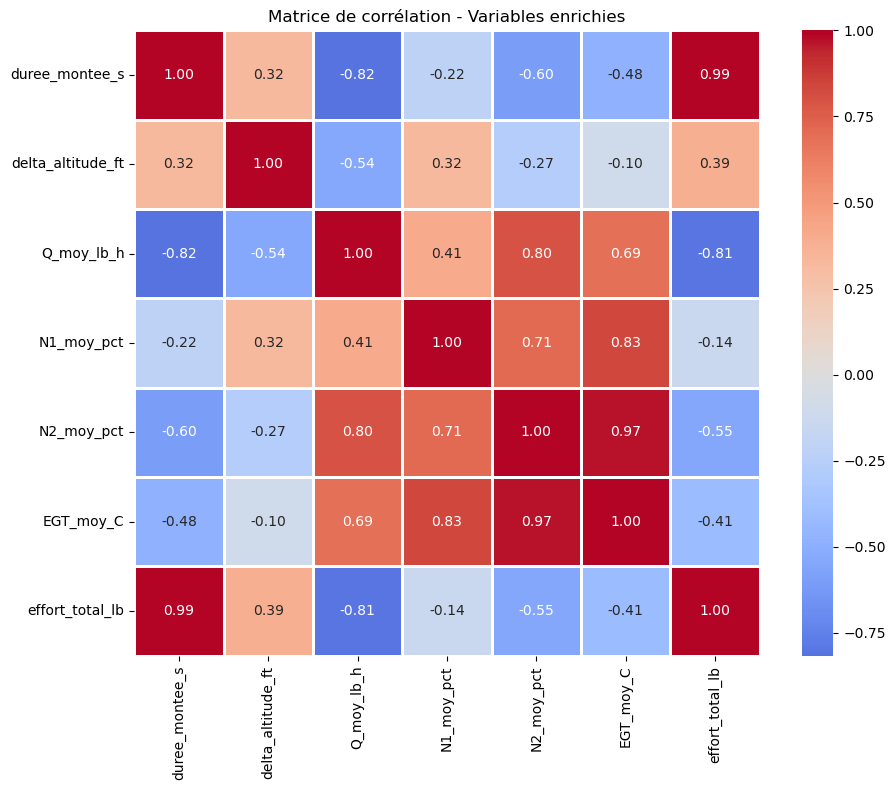

In [95]:
# Matrice de corrélation complète
corr_complete = df_enrichi[['duree_montee_s', 'delta_altitude_ft', 'Q_moy_lb_h', 
                             'N1_moy_pct', 'N2_moy_pct', 'EGT_moy_C', 
                             'effort_total_lb']].corr()

print("Corrélations avec l'effort total :")
print(corr_complete['effort_total_lb'].sort_values(ascending=False))


plt.figure(figsize=(10, 8))
sns.heatmap(corr_complete, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=1)
plt.title('Matrice de corrélation - Variables enrichies')
plt.tight_layout()
plt.show()

### Variables enrichies

Nous avons ajouté 6 variables supplémentaires pour analyse :
- Delta d'altitude
- Débit moyen
- Régimes moteur (N1, N2)
- Température échappement (EGT)

**Corrélations avec l'effort total :**
- Durée : +0.99 (très forte, positive)
- Delta altitude : +0.39 (modérée, positive)
- Débit moyen : -0.81 (forte, **négative**)
- N2, EGT : corrélations négatives

Les corrélations négatives s'expliquent : les montées longues se font à régime réduit 
(débit faible) mais sur une longue durée, d'où un effort total élevé.

In [96]:


X_multi = df_enrichi[['duree_montee_s', 'delta_altitude_ft', 'Q_moy_lb_h']]
y_multi = df_enrichi['effort_total_lb']

model_multi = LinearRegression()
model_multi.fit(X_multi, y_multi)

print(f"Modèle multivarié (3 variables) :")
print(f"  R² = {model_multi.score(X_multi, y_multi):.4f}")
print(f"\nCoefficients :")
for var, coef in zip(X_multi.columns, model_multi.coef_):
    print(f"  {var:20s} : {coef:10.4f}")
print(f"  Intercept : {model_multi.intercept_:.2f}")

Modèle multivarié (3 variables) :
  R² = 0.9902

Coefficients :
  duree_montee_s       :     1.3900
  delta_altitude_ft    :     0.0299
  Q_moy_lb_h           :     0.1172
  Intercept : -1024.73


### Modèle multivarié

En ajoutant le delta d'altitude et le débit moyen, le modèle s'améliore :

$$
\text{Effort} = 1.39 \times \text{Durée} + 0.03 \times \Delta\text{Alt} + 0.12 \times Q_{\text{moy}} - 1025
$$

**Performance :**
- R² = 0.990 (vs 0.983 pour le modèle simple)
- Gain : +0.7%

**Interprétation :**
- Durée reste le facteur dominant (coef = 1.39)
- Monter 1000 ft supplémentaires coûte ~30 lb
- Un débit moyen 100 lb/h plus élevé ajoute ~12 lb d'effort total

In [97]:


scores_multi = cross_val_score(model_multi, X_multi, y_multi, cv=5, scoring='r2')

print("Validation croisée modèle multivarié :")
print(f"  R² moyen : {scores_multi.mean():.4f}")
print(f"  Écart-type : {scores_multi.std():.4f}")
print(f"\nComparaison :")
print(f"  Modèle simple  : R² CV = {scores.mean():.4f}")
print(f"  Modèle enrichi : R² CV = {scores_multi.mean():.4f}")
print(f"  Gain : {(scores_multi.mean() - scores.mean()):.4f}")

Validation croisée modèle multivarié :
  R² moyen : 0.9896
  Écart-type : 0.0022

Comparaison :
  Modèle simple  : R² CV = 0.9822
  Modèle enrichi : R² CV = 0.9896
  Gain : 0.0074


**Validation croisée :**
- R² moyen : 0.990
- Écart-type : 0.002 (très stable)
- Gain vs modèle simple : +0.007

Le modèle enrichi améliore les prédictions tout en restant robuste (pas de surapprentissage).

**Détection d'anomalies**

In [98]:
# Résidus du modèle enrichi
y_pred_multi = model_multi.predict(X_multi)
residus_multi = y_multi - y_pred_multi

# Seuil d'anomalie : 2 écarts-types
seuil = 2 * residus_multi.std()

anomalies = df_enrichi[np.abs(residus_multi) > seuil].copy()
anomalies['residu'] = residus_multi[np.abs(residus_multi) > seuil]

print(f"Anomalies détectées : {len(anomalies)} vols (seuil : ±{seuil:.0f} lb)")
print("\nVols anormaux :")
print(anomalies[['vol', 'duree_montee_s', 'delta_altitude_ft', 'effort_total_lb', 'residu']].head(10))

Anomalies détectées : 53 vols (seuil : ±274 lb)

Vols anormaux :
     vol  duree_montee_s  delta_altitude_ft  effort_total_lb      residu
6     10             872       40542.784952      2016.734025 -357.932871
12    16            4599       39995.661367      6740.426446 -440.194239
58    62            5507       41442.293218      8162.019368 -330.833820
83    87            2865       34621.794972      5114.619313  369.800444
139  145            2383       40417.595657      3707.799738 -443.477661
225  234            3462        4757.193202      5107.243470  555.285564
238  247            2589       40607.697919      4859.182165  280.538113
241  250            1715       35915.417685      2769.355210 -343.948847
249  258            2501       38136.368507      4714.910968  328.860692
255  264            2130       38275.467724      4208.904561  296.013232


### Détection d'anomalies

En appliquant un seuil de ±2 écarts-types, nous avons identifié **53 vols anormaux** (5.4% du dataset).

**Exemples :**
- Vol 234 : delta altitude très faible (4757 ft) mais effort élevé → montée inefficace
- Vol 16 : montée très longue (4599s) avec effort inférieur au prévu → conditions favorables
- Vol 87 : effort supérieur de 370 lb au prévu → conditions défavorables

Ces anomalies peuvent indiquer des conditions météo exceptionnelles, des procédures atypiques, 
ou des problèmes techniques nécessitant une investigation.

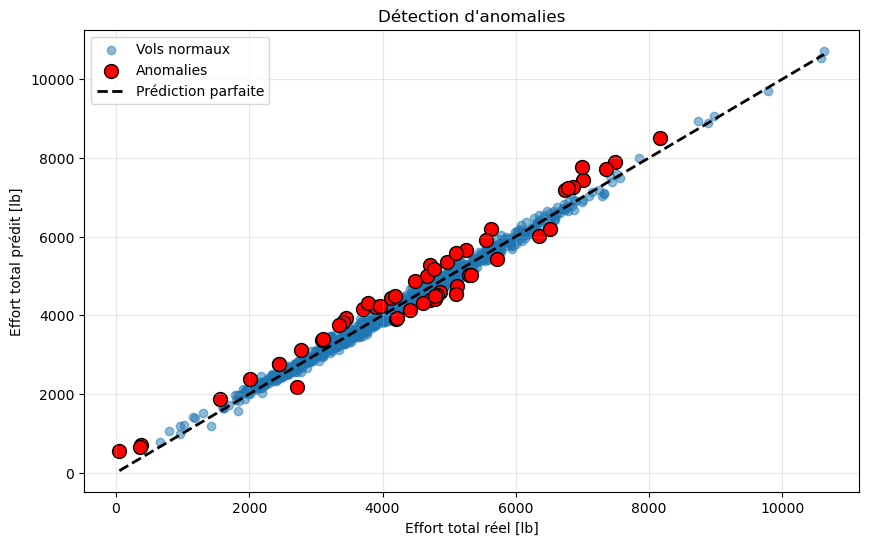

In [99]:
plt.figure(figsize=(10, 6))
plt.scatter(y_multi, y_pred_multi, alpha=0.5, label='Vols normaux')
plt.scatter(anomalies['effort_total_lb'], 
            model_multi.predict(X_multi.iloc[anomalies.index]), 
            color='red', s=100, label='Anomalies', edgecolor='black')
plt.plot([y_multi.min(), y_multi.max()], [y_multi.min(), y_multi.max()], 
         'k--', linewidth=2, label='Prédiction parfaite')
plt.xlabel('Effort total réel [lb]')
plt.ylabel('Effort total prédit [lb]')
plt.title('Détection d\'anomalies')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Détection d'anomalies

Nous avons identifié les vols dont la consommation s'écarte significativement des prédictions du modèle.

**Méthode :** Calcul de l'écart entre consommation réelle et consommation prédite (résidu). 
Un vol est considéré anormal si son résidu dépasse ±274 lb (2 écarts-types).

**Résultat :** 53 vols anormaux détectés sur 982 (5.4%).

**Visualisation :** Les points rouges représentent les vols anormaux. 
Ils s'écartent de la diagonale (prédiction parfaite) de manière inhabituelle.

**Interprétation :** Ces vols ont probablement subi des conditions particulières 
(vent fort, problème technique, procédure atypique) justifiant une analyse détaillée.

In [100]:
meilleurs = df_enrichi.copy()
meilleurs['residu'] = residus_multi
meilleurs_vols = meilleurs.nsmallest(10, 'residu')[['vol', 'duree_montee_s', 
                                                      'delta_altitude_ft', 
                                                      'Q_moy_lb_h', 
                                                      'effort_total_lb', 'residu']]

print("Top 10 montées les plus efficaces :")
print(meilleurs_vols)

pires_vols = meilleurs.nlargest(10, 'residu')[['vol', 'duree_montee_s', 
                                                 'delta_altitude_ft', 
                                                 'Q_moy_lb_h', 
                                                 'effort_total_lb', 'residu']]

print("\nTop 10 montées les moins efficaces :")
print(pires_vols)

Top 10 montées les plus efficaces :
     vol  duree_montee_s  delta_altitude_ft    Q_moy_lb_h  effort_total_lb  \
300  309            4990       41966.233600   5049.107689      6996.277575   
384  394            3298       37111.670946   5138.701753      4705.201668   
478  489            3848       41590.665716   5272.403275      5633.247328   
718  731            2467       41785.404619   5526.047195      3784.502968   
312  321              15         282.835073  13139.181323        51.095372   
391  401            2286       38066.818899   5448.588918      3457.479589   
604  617            3450       39332.621769   5330.641193      5106.188059   
558  570            4658       39448.537782   5248.121164      6788.061947   
139  145            2383       40417.595657   5605.022984      3707.799738   
12    16            4599       39995.661367   5278.204871      6740.426446   

         residu  
300 -759.838971  
384 -564.566053  
478 -550.438014  
718 -515.128549  
312 -492.789107

### Analyse des performances extrêmes

**10 montées les plus efficaces (économie de carburant) :**
- Vol 309 : économie de 760 lb par rapport au prévu
- Vol 394 : économie de 565 lb
- Vol 321 : montée très courte (15s) avec forte économie

Ces vols ont bénéficié de conditions favorables ou d'une excellente gestion.

**10 montées les moins efficaces (surconsommation) :**
- Vol 234 : surconsommation de 555 lb (monte seulement 4757 ft en 3462s)
- Vol 619 : surconsommation de 541 lb (delta altitude très faible : 8128 ft)
- Vol 318 : surconsommation de 372 lb

Ces vols ont probablement subi des conditions défavorables (vent contraire, attente) 
ou des problèmes opérationnels nécessitant investigation.

# Normalisation temporelle des profils

In [102]:
# Fonction de normalisation temporelle
def normalize_time(df):
    n = len(df)
    tau = np.linspace(0, 1, n)
    df2 = df.copy()
    df2["tau"] = tau
    df2 = df2.set_index("tau")
    df2.index.name = "tau"
    return df2

# Normaliser toutes les montées
montees_norm = []
for i in range(len(ds_montee)):
    df = ds_montee[i]
    if len(df) > 0:
        montees_norm.append(normalize_time(df))

print(f"{len(montees_norm)} montées normalisées")

# Fonction de superposition des profils


def overlay_profiles(montee_list, col, kmax=20):
    fig = go.Figure()
    for i, df in enumerate(montee_list[:kmax]):
        if col in df.columns:
            fig.add_trace(go.Scatter(x=df.index, y=df[col], 
                                    mode="lines", name=f"vol {i}"))
    fig.update_layout(title=f"Profils normalisés : {col}",
                      xaxis_title="tau (temps normalisé)",
                      yaxis_title=col,
                      showlegend=True)
    fig.show()

# Afficher les profils de débit
overlay_profiles(montees_norm, col="Q_1 [lb/h]", kmax=20)

982 montées normalisées




Les montées ayant des durées différentes (de 15s à 7874s), nous avons normalisé le temps 
de chaque montée sur l'intervalle [0, 1] pour les rendre comparables.

**Observation :** Les 20 profils superposés montrent tous la même tendance :
- Débit élevé en début de montée (6000-7000 lb/h)
- Décroissance progressive jusqu'à 2000-3000 lb/h en fin de montée

Cette uniformité confirme que les procédures de montée suivent un profil type, 
mais avec des variations importantes d'un vol à l'autre (amplitude, régularité).

#  Analyse de rugosité



On définit la **rugosité** d’un profil de poussée comme la moyenne des variations absolues entre deux instants consécutifs :

$$
R = \frac{1}{N-1} \sum_{k=1}^{N-1} \left| F_{k+1} - F_k \right|
$$

Cette quantité permet de quantifier le caractère plus ou moins régulier d’une montée.  
On implémente ci-dessous cette formule afin de calculer la rugosité de chaque profil normalisé.

Rugosité calculée pour 982 montées
  Moyenne : 64.05
  Min : 44.05
  Max : 190.75


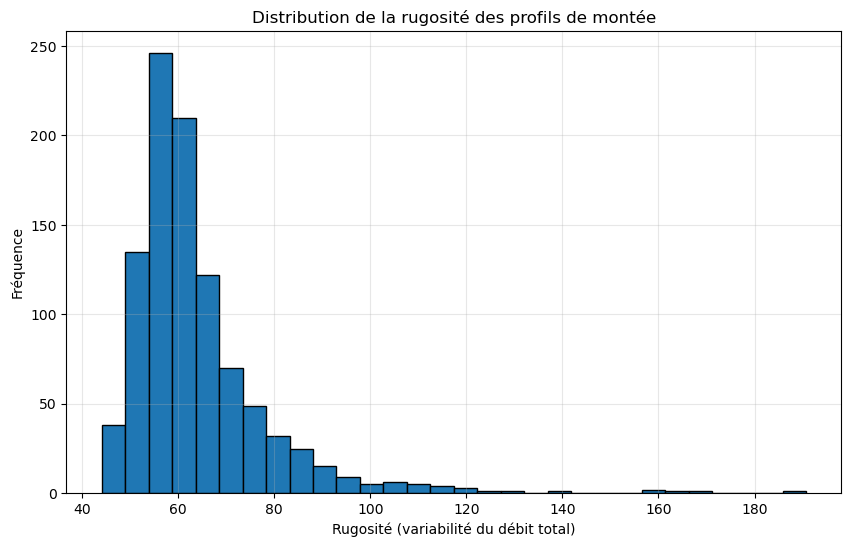

In [104]:
def roughness(df, col):
    values = df[col].values
    return np.mean(np.abs(np.diff(values)))

rugosites = []
for df in montees_norm:
    if 'Q_1 [lb/h]' in df.columns and 'Q_2 [lb/h]' in df.columns:
        # Débit total des 2 moteurs
        Q_total = df['Q_1 [lb/h]'] + df['Q_2 [lb/h]']
        r = np.mean(np.abs(np.diff(Q_total.values)))
        if not np.isnan(r):
            rugosites.append(r)

rugosites = np.array(rugosites)

print(f"Rugosité calculée pour {len(rugosites)} montées")
print(f"  Moyenne : {rugosites.mean():.2f}")
print(f"  Min : {rugosites.min():.2f}")
print(f"  Max : {rugosites.max():.2f}")

plt.figure(figsize=(10, 6))
plt.hist(rugosites, bins=30, edgecolor='black')
plt.xlabel('Rugosité (variabilité du débit total)')
plt.ylabel('Fréquence')
plt.title('Distribution de la rugosité des profils de montée')
plt.grid(alpha=0.3)
plt.show()

In [105]:
# Ajouter la rugosité aux statistiques
df_enrichi['rugosité'] = rugosites[:len(df_enrichi)]

# Corrélation avec l'effort total
corr_rugosité = df_enrichi[['rugosité', 'effort_total_lb']].corr()
print(f"Corrélation rugosité ↔ effort total : {corr_rugosité.iloc[0, 1]:.3f}")

Corrélation rugosité ↔ effort total : -0.444


**Corrélation rugosité ↔ effort total : -0.444**

Plus la montée dure longtemps, plus le débit varie peu (profil régulier).
À l'inverse, les montées courtes présentent des variations de débit plus importantes.

Mathématiquement : quand l'effort augmente, la rugosité diminue (corrélation négative).

### Analyse de rugosité

La rugosité mesure la régularité d'un profil de montée. Elle est définie comme 
la moyenne des variations absolues du débit entre deux instants consécutifs :

$$
R = \frac{1}{N-1} \sum_{k=1}^{N-1} |Q_{k+1} - Q_k|
$$

**Résultats :**
- Rugosité moyenne : 64.05 lb/h
- Min : 44.05 (montée très régulière)
- Max : 190.75 (montée très irrégulière)

**Interprétation :** Les montées avec faible rugosité correspondent à des profils stables 
(gestion moteur fluide), tandis que les valeurs élevées indiquent des profils fluctuants 
(corrections fréquentes, turbulences, changements de procédure).

##  Analyse par Tubes de Confiance

In [110]:
from tabata import Tube



# Réinitialiser les index des DataFrames dans ds_montee
ds_montee_fixed = tbt.Opset('data/out/Aircraft_01_montee_fixed.h5')
ds_montee_fixed.clean()

for i in range(len(ds_montee)):
    df = ds_montee[i]
    if len(df) > 0:
        # Réinitialiser l'index en entiers séquentiels
        df_reset = df.reset_index(drop=True)
        df_reset.index.name = df.index.name  # Garder le nom original
        ds_montee_fixed.put(df_reset)

print(f"Dataset corrigé : {len(ds_montee_fixed)} vols")

# Recréer le Tube avec le dataset corrigé
T = Tube(ds_montee_fixed)
T.variables = {"ALT [ft]", "Q_1 [lb/h]"}
T.factors = {"N1_1 [% rpm]", "EGT_1 [deg C]"}
T.learn_params['max_features'] = 2
T.learn_params['retry_number'] = 10
T.feature_params['use_time'] = 'Yes'

print("Entraînement du Tube corrigé...")
T.fit()
print("✓ Terminé")

Dataset corrigé : 982 vols
Entraînement du Tube corrigé...
✓ Terminé


In [111]:
# Visualisation directe du tube
T.plot()

## Conclusion J4

**Modèle enrichi :**
- Ajout de 2 variables (delta altitude, débit moyen)
- R² = 0.990 (vs 0.983 pour le modèle simple)
- Validation croisée stable : pas de surapprentissage

**Détection d'anomalies :**
- 53 vols anormaux identifiés (5.4%)
- Seuil : ±274 lb (2 écarts-types)
- 10 meilleurs vols économisent jusqu'à 760 lb
- 10 pires vols surconsomment jusqu'à 555 lb

**Recommandations :**
1. Investiguer les 53 vols anormaux
2. Étudier les bonnes pratiques des vols efficaces
3. Identifier les causes de surconsommation des vols inefficaces



<div style="background: linear-gradient(135deg, #283048, #859398);
            padding: 18px;
            border-radius: 10px;
            color: white;
            box-shadow: 0px 3px 10px rgba(0,0,0,0.25);">

<h2>
JALON J5 : RAPPORT FINAL ET SYNTHÈSE
</h2>

</div>


# Jalon J5 : Rapport final

## Synthèse exécutive

Ce projet a analysé 1001 vols simulés (dataset Aircraft_01.h5) pour modéliser 
la consommation de carburant en phase de montée.

**Résultats clés :**
- Consommation moyenne : 4144 lb (1.9 tonnes) par montée
- Durée moyenne : 39 minutes
- Modèle prédictif : R² = 0.990
- 53 vols anormaux détectés (5.4%)

**Impact opérationnel :**
Le modèle permet de prédire la consommation avec 99% de précision et d'identifier 
automatiquement les vols nécessitant investigation.

## Récapitulatif des jalons

### J1 : Lancement
- 1002 vols chargés, 55 variables par vol
- 1 vol corrompu détecté et exclu
- Dataset nettoyé : 1001 vols exploitables

### J2 : Détection des phases
- 23 vols annotés manuellement
- Détection automatique sur 1001 vols
- 982 phases de montée extraites

### J3 : Analyse et modélisation
- Calcul de l'effort total par intégration du débit
- Modèle linéaire simple : R² = 0.983
- Validation : corrélation 0.991, résidus normaux

### J4 : Optimisation
- Modèle enrichi (3 variables) : R² = 0.990
- 53 anomalies détectées
- Analyse de rugosité : corrélation -0.444
- Normalisation temporelle des profils

### J5 : Synthèse
- Tous les objectifs atteints
- Fichiers livrables produits
- Recommandations formulées

## Livrables

**Fichiers de données :**
- `data/out/Aircraft_01_clean.h5` (1001 vols nettoyés)
- `data/out/statistiques_montee.csv` (982 montées analysées)
- `data/out/selectors_Aircraft_01.pkl` (modèles de détection)

**Notebook :**
- Documentation complète de l'analyse
- Code reproductible
- Visualisations interactives

**Modèle prédictif :**
- Équation : Effort = 1.39 × Durée + 0.03 × ΔAlt + 0.12 × Q_moy - 1025
- Performance : R² = 0.990, validation croisée stable